In [1]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Files

In [2]:
# todo: create a nicer for loop for this section
hscy3 = "/scratch/gpfs/dy9683/matched_catalogs/hscy3_matched_lensing_match_1.csv"
desy3 = "/scratch/gpfs/dy9683/matched_catalogs/desy3_matched_lensing_match_1.csv"
decade = "/scratch/gpfs/dy9683/matched_catalogs/decade_matched_lensing_match_1.csv"
kidslegacy = "/scratch/gpfs/dy9683/matched_catalogs/kidslegacy_matched_lensing_match_1.csv"

In [3]:
hsc_catalog = pd.read_csv(hscy3)

In [4]:
des_catalog = pd.read_csv(desy3)

In [5]:
decade_catalog = pd.read_csv(decade)

In [6]:
kidslegacy_catalog = pd.read_csv(kidslegacy)

In [7]:
ra_hsc = hsc_catalog['TARGET_RA']
dec_hsc = hsc_catalog['TARGET_DEC']
g1_hsc = hsc_catalog['e1'] 
g2_hsc = hsc_catalog['e2']
z_hsc = hsc_catalog['Z_BEST']

In [8]:
ra_des = des_catalog['TARGET_RA']
dec_des = des_catalog['TARGET_DEC']
g1_des = des_catalog['e1'] 
g2_des = des_catalog['e2']
z_des = des_catalog['Z_BEST']

In [9]:
ra_decade = decade_catalog['TARGET_RA']
dec_decade = decade_catalog['TARGET_DEC']
g1_decade = decade_catalog['e1'] 
g2_decade = decade_catalog['e2']
z_decade = decade_catalog['Z_BEST']

In [10]:
ra_kidslegacy = kidslegacy_catalog['TARGET_RA']
dec_kidslegacy = kidslegacy_catalog['TARGET_DEC']
g1_kidslegacy = kidslegacy_catalog['e1'] 
g2_kidslegacy = kidslegacy_catalog['e2']
z_kidslegacy = kidslegacy_catalog['Z_BEST']

# TreeCorr Code

In [28]:
# for loop for this too
cat_hsc = treecorr.Catalog(ra=ra_hsc, dec=dec_hsc, g1=g1_hsc, g2=g2_hsc, ra_units='degrees', dec_units='degrees')
gg_hsc = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_hsc.process(cat_hsc)

r_hsc = np.exp(gg_hsc.meanlogr)

# correlation functions
#xi_+
xip_hsc = gg_hsc.xip
# # xi_-
xim_hsc = gg_hsc.xim

#calculate variance
sig_xip_hsc = np.sqrt(gg_hsc.varxip)
sig_xim_hsc = np.sqrt(gg_hsc.varxim)

In [29]:
# for loop for this too
cat_des = treecorr.Catalog(ra=ra_des, dec=dec_des, g1=g1_des, g2=g2_des, ra_units='degrees', dec_units='degrees')
gg_des = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_des.process(cat_des)

r_des = np.exp(gg_des.meanlogr)

# correlation functions
#xi_+
xip_des = gg_des.xip
# # xi_-
xim_des = gg_des.xim

#calculate variance
sig_xip_des = np.sqrt(gg_des.varxip)
sig_xim_des = np.sqrt(gg_des.varxim)

In [33]:
# for loop for this too
cat_decade = treecorr.Catalog(ra=ra_decade, dec=dec_decade, g1=g1_decade, g2=g2_decade, ra_units='degrees', dec_units='degrees')
gg_decade = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_decade.process(cat_decade)

r_decade = np.exp(gg_decade.meanlogr)

# correlation functions
#xi_+
xip_decade = gg_decade.xip
# # xi_-
xim_decade = gg_decade.xim

#calculate variance
sig_xip_decade = np.sqrt(gg_decade.varxip)
sig_xim_decade = np.sqrt(gg_decade.varxim)

In [34]:
# for loop for this too
cat_kidslegacy = treecorr.Catalog(ra=ra_kidslegacy, dec=dec_kidslegacy, g1=g1_kidslegacy, g2=g2_kidslegacy, ra_units='degrees', dec_units='degrees')
gg_kidslegacy = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_kidslegacy.process(cat_kidslegacy)

r_kidslegacy = np.exp(gg_kidslegacy.meanlogr)

# correlation functions
#xi_+
xip_kidslegacy = gg_kidslegacy.xip
# # xi_-
xim_kidslegacy = gg_kidslegacy.xim

#calculate variance
sig_xip_kidslegacy = np.sqrt(gg_kidslegacy.varxip)
sig_xim_kidslegacy = np.sqrt(gg_kidslegacy.varxim)

# Plots

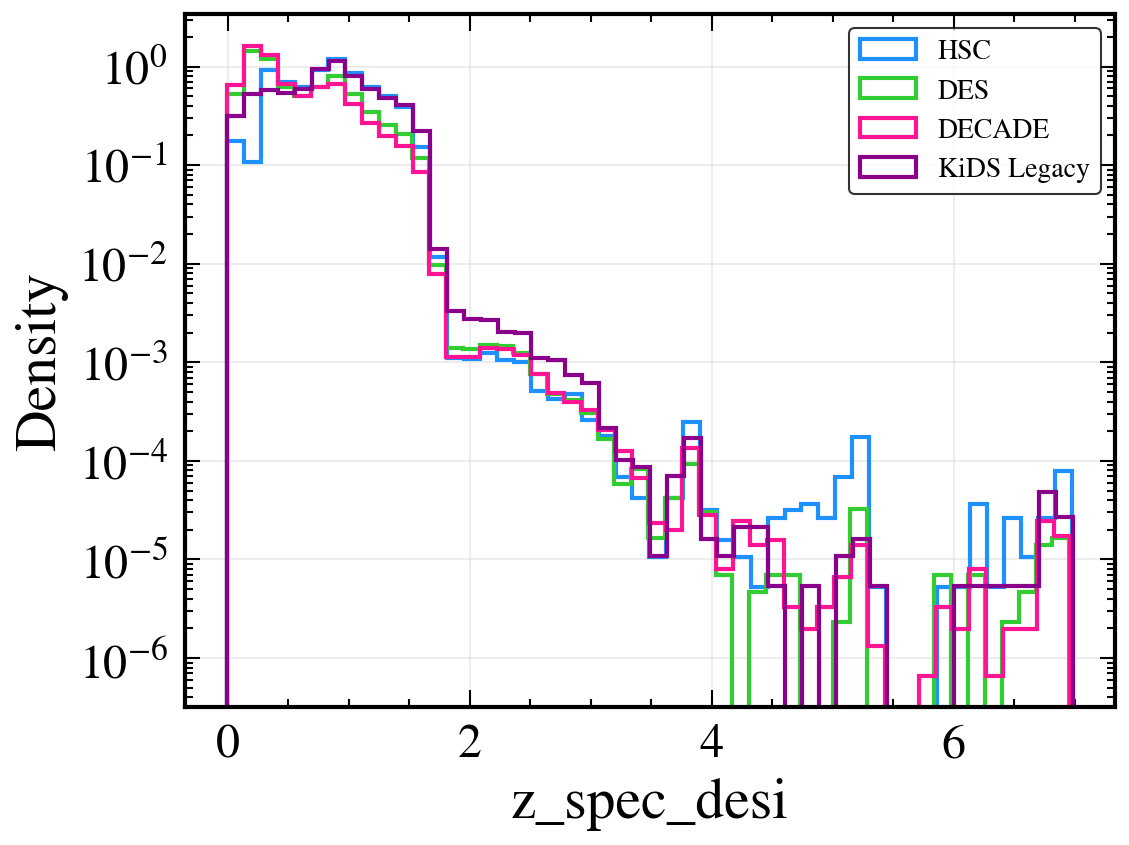

In [51]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z_hsc, bins = 50 , density = True, color = "dodgerblue", histtype = "step", label = "HSC", lw = 2)
ax.hist(z_des, bins = 50 , density = True, color = "limegreen", histtype = "step", label = "DES", lw = 2)
ax.hist(z_decade, bins = 50 , density = True, color = "deeppink", histtype = "step", label = "DECADE", lw = 2 )
ax.hist(z_kidslegacy, bins = 50 , density = True, color = "darkmagenta", histtype = "step", label = "KiDS Legacy", lw = 2)
ax.legend()
ax.set_xlabel("z_spec_desi")
ax.set_ylabel("Density")
ax.set_yscale('log')
plt.show()

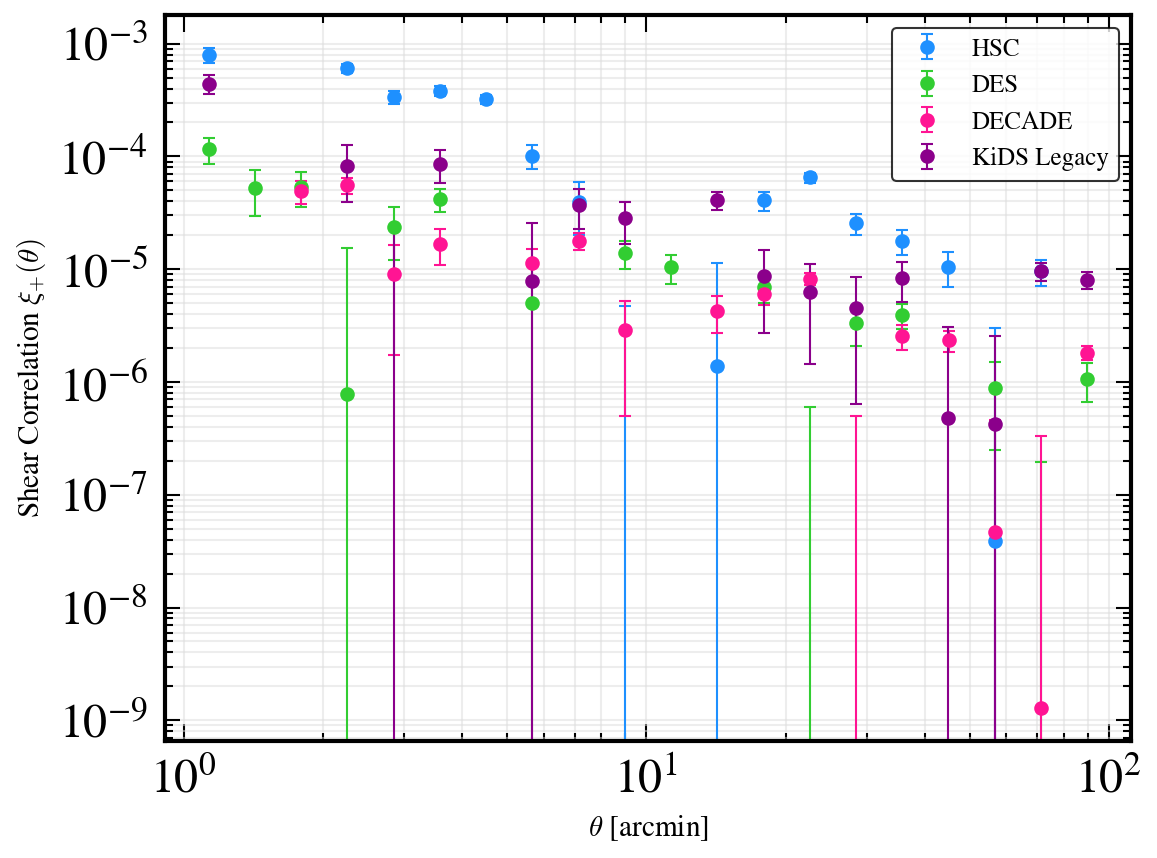

In [40]:
# xi_+
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax.errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax.errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax.errorbar(r_kidslegacy, xip_kidslegacy, yerr=sig_xip_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

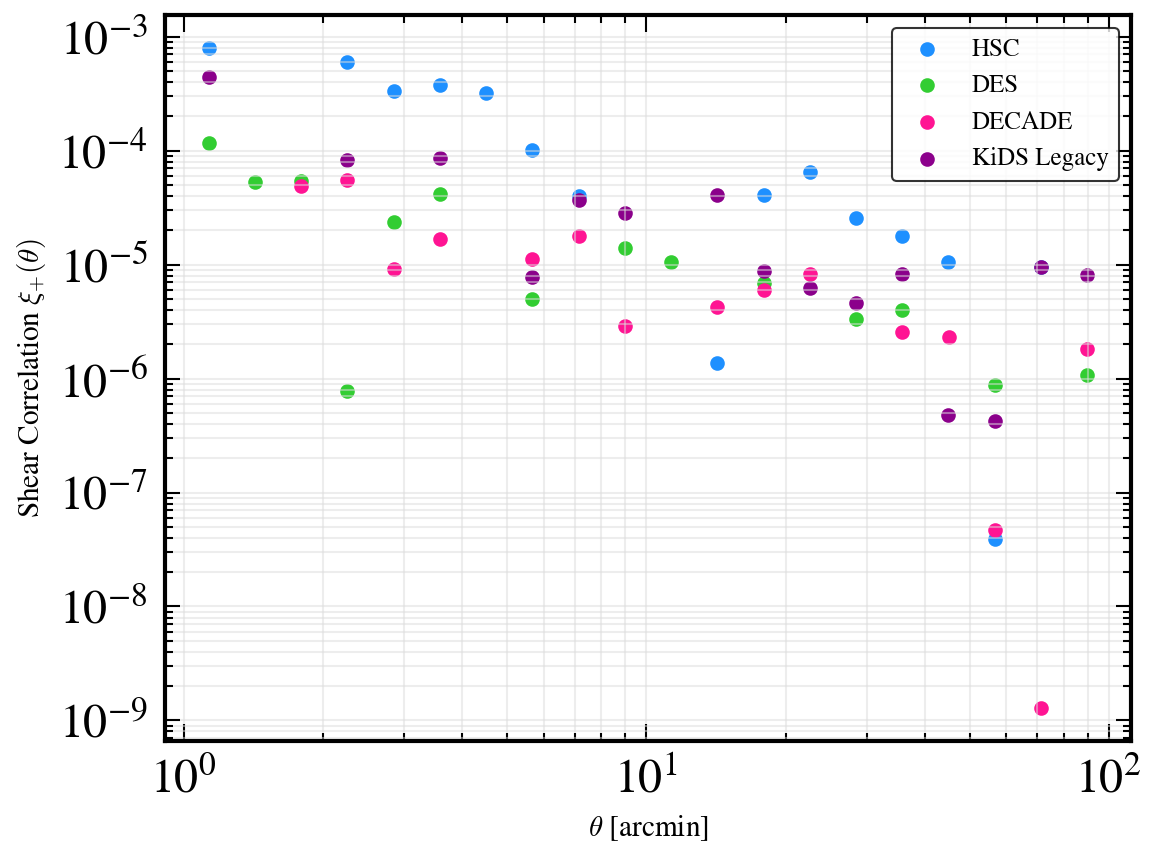

In [44]:
# xi_+
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r_hsc, xip_hsc, label="HSC", color='dodgerblue')
ax.scatter(r_des, xip_des, label="DES", color='limegreen')
ax.scatter(r_decade, xip_decade, label="DECADE", color='deeppink')
ax.scatter(r_kidslegacy, xip_kidslegacy, label="KiDS Legacy", color='darkmagenta')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

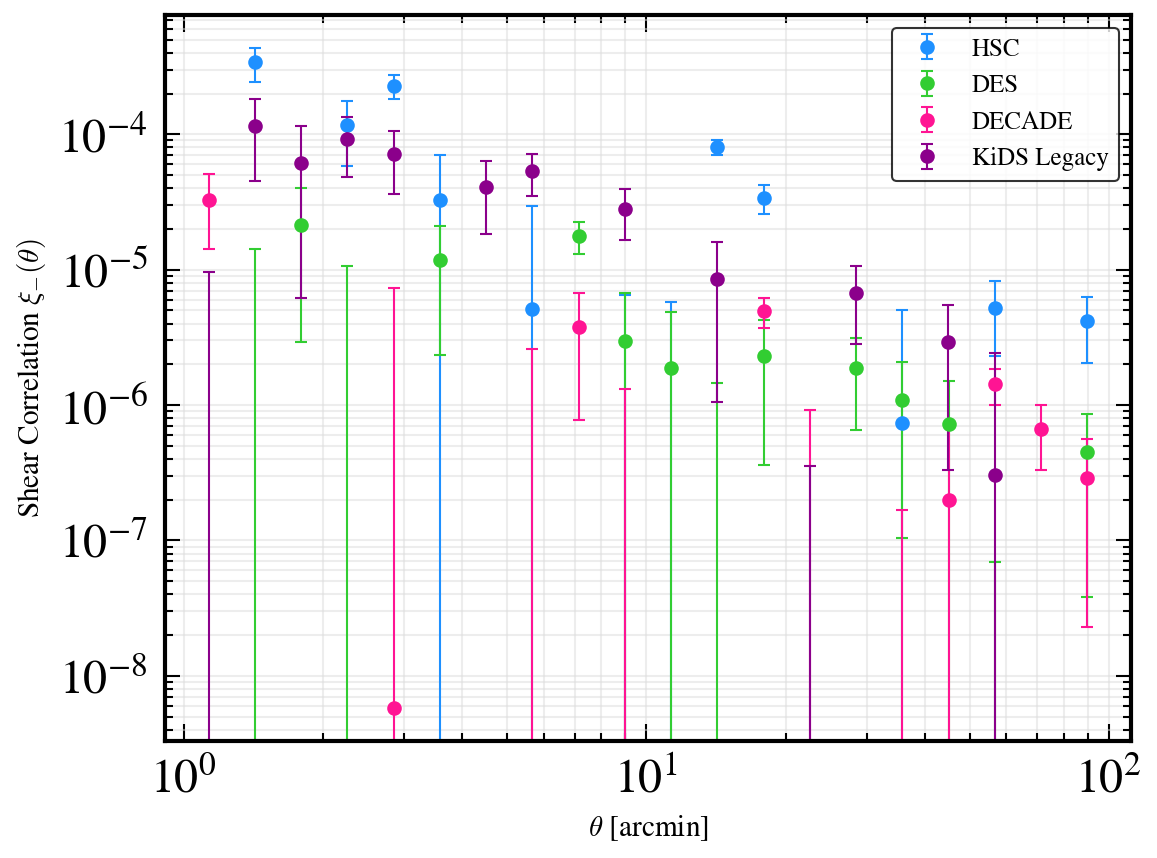

In [47]:
# xi_-
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_hsc, xim_hsc, yerr=sig_xim_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax.errorbar(r_des, xim_des, yerr=sig_xim_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax.errorbar(r_decade, xim_decade, yerr=sig_xim_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax.errorbar(r_kidslegacy, xim_kidslegacy, yerr=sig_xim_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{-}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

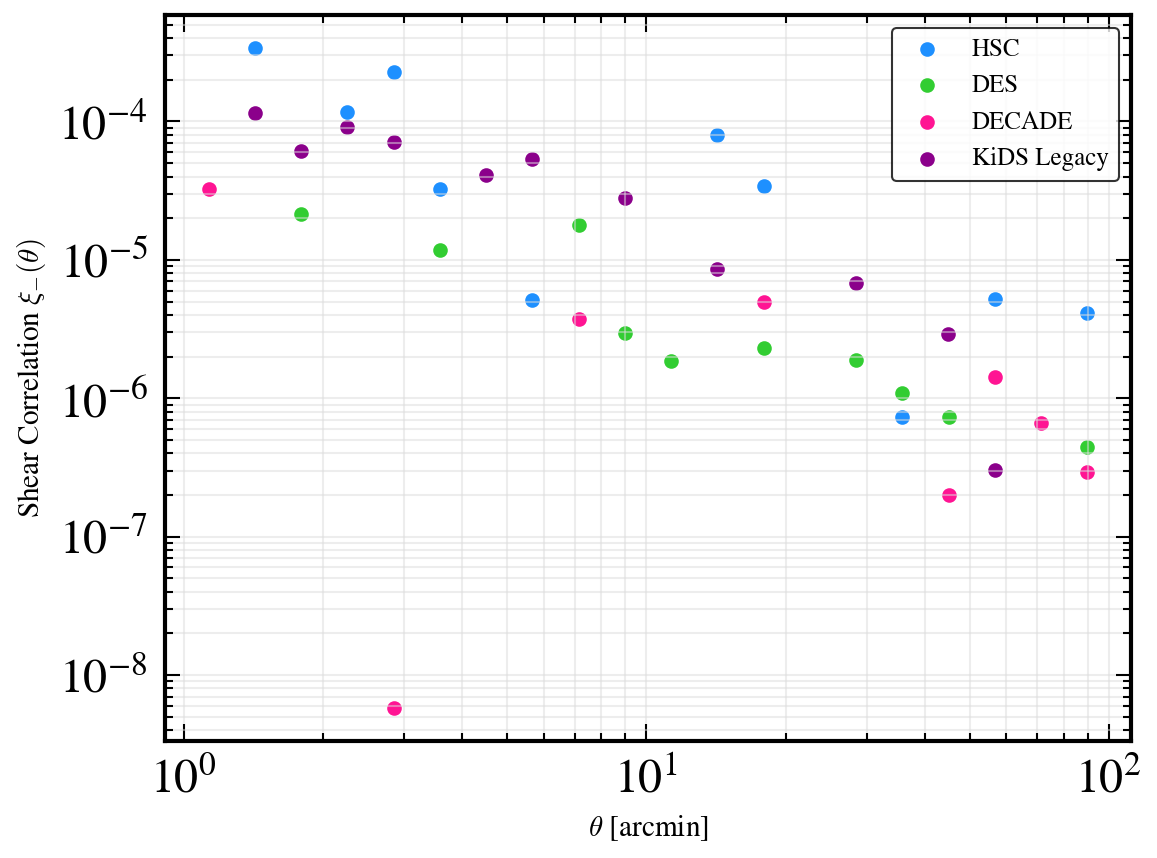

In [49]:
# xi_+
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r_hsc, xim_hsc, label="HSC", color='dodgerblue')
ax.scatter(r_des, xim_des, label="DES", color='limegreen')
ax.scatter(r_decade, xim_decade, label="DECADE", color='deeppink')
ax.scatter(r_kidslegacy, xim_kidslegacy, label="KiDS Legacy", color='darkmagenta')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{-}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()